In [68]:
# Aquí de desarrollará el código para el modelo de DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset df_dqi_final
df_dqi_final = pd.read_csv('./Data/Processed/df_dqi_final.csv', delimiter=';')

Se analizan las características del dataset **df_dqi_final**

In [69]:
# Visualizamos los primeros registros
df_dqi_final.head()


,folio_integrante,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,...,False,True,False,False,False,False,False,False,False,False
2,2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,...,False,True,False,False,False,False,False,False,False,False
3,2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,...,False,True,False,False,False,False,False,False,False,False


In [70]:
# shape del dataset
df_dqi_final.shape

(1584, 90)

In [71]:
df_dqi_final.describe()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,protein_percentage,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,resultado_general_entrevista
count,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,...,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1584.000000,1.584000e+03,1584.000000
mean,12458.039456,1668.595049,472.733087,414.955654,132.936355,6505.044595,82.303747,5.454966,62.152909,70.947810,...,0.138929,4.807449,3.312500,3.141414,3.983586,24.364899,52.142045,27.416035,8.033397e+04,0.914773
std,8583.669482,1178.009436,401.267503,273.835523,109.615638,4550.141795,60.077022,5.650290,49.973624,56.185275,...,0.037602,0.565525,1.520197,1.702498,1.540683,8.123614,12.783415,23.388704,1.112694e+05,0.279308
min,401.310000,52.500000,9.990000,14.748289,0.000000,41.510000,1.440000,0.000000,1.152000,1.197000,...,0.019940,0.000000,0.000000,0.000000,0.000000,1.000000,15.000000,1.000000,2.709469e+03,0.000000
25%,7003.719175,904.932775,243.440025,231.084375,63.293465,3508.116700,44.059933,1.899600,32.379787,35.425665,...,0.114583,5.000000,2.000000,2.000000,3.000000,18.000000,43.000000,6.000000,2.078565e+04,1.000000
50%,10370.420200,1364.095470,380.280540,356.986850,104.642750,5511.035000,68.469300,3.953200,49.491630,58.200010,...,0.136650,5.000000,3.000000,3.000000,5.000000,25.000000,53.000000,21.000000,4.084539e+04,1.000000
75%,15456.449005,2110.694775,576.785265,526.610269,167.877598,8162.743000,103.542420,7.090800,77.932965,90.849508,...,0.160882,5.000000,5.000000,5.000000,5.000000,31.000000,61.000000,46.000000,9.063676e+04,1.000000
max,116261.801900,13072.399900,6575.838200,3282.419800,1580.485500,71059.028000,900.172150,72.169600,838.596850,659.712550,...,0.459642,5.000000,5.000000,5.000000,5.000000,40.000000,86.000000,91.000000,1.145273e+06,1.000000


In [72]:
# cantidad de variables numericas y categoricas
df_dqi_final.dtypes.value_counts()

float64    54
int64      24
bool       10
object      2
Name: count, dtype: int64

In [73]:
# Lista de columnas en df_dqi_final
df_dqi_final.columns

Index(['folio_integrante', 'energ_kcal', 'carbohydrt', 'lipid_tot', 'protein',
       'fiber_td', 'calcium', 'iron', 'ironhem', 'ironnohem', 'zinc', 'vit_c',
       'thiamin', 'riboflavin', 'niacin', 'panto_acid', 'vit_b6', 'folic_acid',
       'food_folate', 'folate_dfe', 'vit_b12', 'vit_a_rae', 'vit_e',
       'vit_d_iu', 'vit_k', 'fa_sat', 'fa_mono', 'fa_poly', 'chole', 'sodio',
       'carbohydrt_ratio', 'lipid_tot_ratio', 'protein_ratio',
       'macronutrients_dqi', 'poly_ratio', 'mono_ratio', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories', 'porc_empty_calories',
       'empty_calories_dqi', 'fat_percentage', 'fa_sat_percentage',
       'total_fat_dqi', 'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi',
       'moderation_dqi', 'Aceites y Grasas', 'Azucares', 'Cereales', 'Frutas',
       'Lacteos/Frijol', 'Misceláneos', 'Proteina', 'Verduras',
       'dqi_food_groups', 'subgrupo de Carne', 'subgrupo de Frijoles',
       'subgrupo de Huevo', 'subgrupo de Lacteos', 's

Nos aseguramos en el código anterior de que no exitan datos nulos

In [74]:
# Revisando valores nulos en el dataset
null_counts = df_dqi_final.isnull().sum()
print(null_counts)

if null_counts.sum() > 0:
    print("Se encontraron datos nulos en el dataset.")
else:
    print("No se encontraron datos nulos en el dataset.")

folio_integrante                     0
energ_kcal                           0
carbohydrt                           0
lipid_tot                            0
protein                              0
                                    ..
region_Pacífico-Centro               0
region_Península                     0
sexo_Mujer                           0
estrato_Rural  ( <2500 Hab )         0
estrato_Urbano ( 2500-99,999 Hab)    0
Length: 90, dtype: int64
No se encontraron datos nulos en el dataset.


In [75]:
# Eliminamos columna resultado_general_entrevista
df_dqi_final = df_dqi_final.drop(['resultado_general_entrevista'], axis=1)

DBSCAN es un modelo que se sugiere solo trabajar con variables numéricas y para fines prácticos y debido al gran tamaño del dataset se descartarán categóricas y booleanas. 


In [76]:
# Eliminamos las columnas que no son numericas
df_dqi_final = df_dqi_final.select_dtypes(include=[np.number])

# Mostramos el dataset con las columnas numericas
df_dqi_final.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,dqi_adequacy_fiber,protein_percentage,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador
0,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,4,0.150984,5,5,2,5,31,60,51,8717.185479
1,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,3,0.140069,5,5,5,5,26,50,1,5378.108847
2,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,1,0.128776,5,2,3,2,15,36,4,4692.485672
3,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,5,0.157492,5,5,3,5,32,58,26,51475.173556
4,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,4,0.139756,5,2,3,5,29,69,2,6860.703803


Escalamos los datos para poder realizar el análisis con DBSCAN

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_dqi_final)


In [78]:
df_dqi_final_scaled = pd.DataFrame(scaled_data, columns=df_dqi_final.columns)

In [79]:
# Visualizamos los primeros registros
df_dqi_final_scaled.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,dqi_adequacy_fiber,protein_percentage,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador
0,-0.526199,-0.522085,-0.388772,-0.420636,-0.018467,0.314017,-0.245232,-0.605995,-0.469793,-0.308437,...,0.504680,0.320695,0.340589,1.110404,-0.670647,0.659925,0.817025,0.614893,1.008667,-0.643838
1,-0.264484,-0.098657,-0.387844,-0.212539,-0.436874,0.860873,-0.041417,-0.591478,-0.447870,0.062776,...,-0.109309,0.030321,0.340589,1.110404,1.092027,0.659925,0.201341,-0.167617,-1.129792,-0.673856
2,-0.763400,-0.852381,-0.465945,-0.821098,-0.783893,-0.654418,-0.711279,-0.767808,-0.851012,-0.669796,...,-1.337285,-0.270099,0.340589,-0.863647,-0.083089,-1.287878,-1.153164,-1.263132,-1.001485,-0.680020
3,-0.055190,-0.076112,-0.053994,0.207888,0.360066,0.279856,0.060707,-0.040146,0.095522,-0.045488,...,1.118668,0.493830,0.340589,1.110404,-0.083089,0.659925,0.940162,0.458391,-0.060563,-0.259442
4,-0.775644,-0.678056,-0.715483,-0.775271,-0.092865,-0.696285,-0.651922,-0.830355,-0.518158,-0.717157,...,0.504680,0.022005,0.340589,-0.863647,-0.083089,0.659925,0.570751,1.319153,-1.087023,-0.660527


Este código aplica el modelo DBSCAN a todas las combinaciones posibles de 3 columnas numéricas del DataFrame df_dqi_final_scaled, ejecutando las combinaciones en paralelo para mejorar la eficiencia. Los resultados incluyen el número de clusters, el número de puntos de ruido y las etiquetas de los clusters para cada combinación de columnas, y se almacenan en un DataFrame para su análisis.

In [82]:
from joblib import Parallel, delayed
from sklearn.cluster import DBSCAN
import pandas as pd
from itertools import combinations

# Lista de columnas numéricas
columns = df_dqi_final_scaled.columns

# Definir la función de DBSCAN para una combinación
def run_dbscan(combo):
    df_subset = df_dqi_final_scaled[list(combo)]
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan.fit(df_subset)
    labels = dbscan.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    return {'columns': combo, 'n_clusters': n_clusters_, 'n_noise': n_noise_, 'labels': labels}

# Ejecutar en paralelo usando joblib
all_results = Parallel(n_jobs=-1)(delayed(run_dbscan)(combo) for combo in combinations(columns, 3))

# Convertir a DataFrame para visualizar resultados
results_df = pd.DataFrame(all_results)
print(results_df)


                                          columns  n_clusters  n_noise  \
0             (energ_kcal, carbohydrt, lipid_tot)           3       43   
1               (energ_kcal, carbohydrt, protein)           3       63   
2              (energ_kcal, carbohydrt, fiber_td)           2       71   
3               (energ_kcal, carbohydrt, calcium)           2       61   
4                  (energ_kcal, carbohydrt, iron)           2       60   
...                                           ...         ...      ...   
73145  (dqi_adequacy_vitamin_c, edad, ponderador)           7       77   
73146             (dqi_adecuacy, dqi_total, edad)           1        7   
73147       (dqi_adecuacy, dqi_total, ponderador)           2       52   
73148            (dqi_adecuacy, edad, ponderador)           1       91   
73149               (dqi_total, edad, ponderador)           4       90   

                                                  labels  
0      [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0

En lo siguiente se grafican los resultados obtenidos del análisis de DBSCAN mostrando el top 10 de número de clusters encontrados dentro del dataset con todas las combinaciones posibles en grupos de 3 de las columnas. 

In [87]:
results_df.head()

,columns,n_clusters,n_noise,labels
0,"(energ_kcal, carbohydrt, lipid_tot)",3,43,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
1,"(energ_kcal, carbohydrt, protein)",3,63,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
2,"(energ_kcal, carbohydrt, fiber_td)",2,71,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
3,"(energ_kcal, carbohydrt, calcium)",2,61,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
4,"(energ_kcal, carbohydrt, iron)",2,60,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."


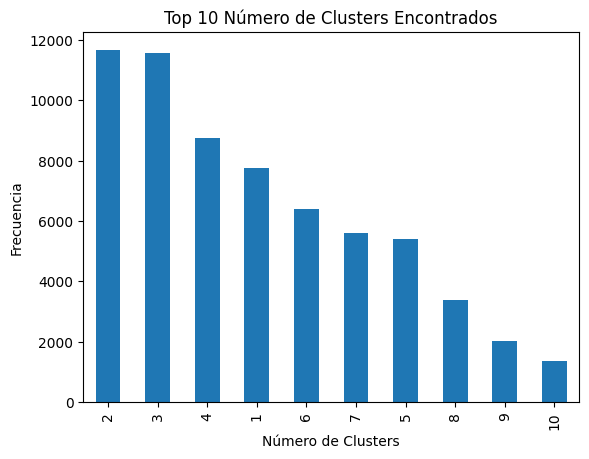

In [85]:
# Visualizar los resultados de results_df para combinaciones de 3 columnas
top_10_clusters = results_df['n_clusters'].value_counts().head(10)
top_10_clusters.plot(kind='bar', title='Top 10 Número de Clusters Encontrados')
plt.xlabel('Número de Clusters')
plt.ylabel('Frecuencia')
plt.show()

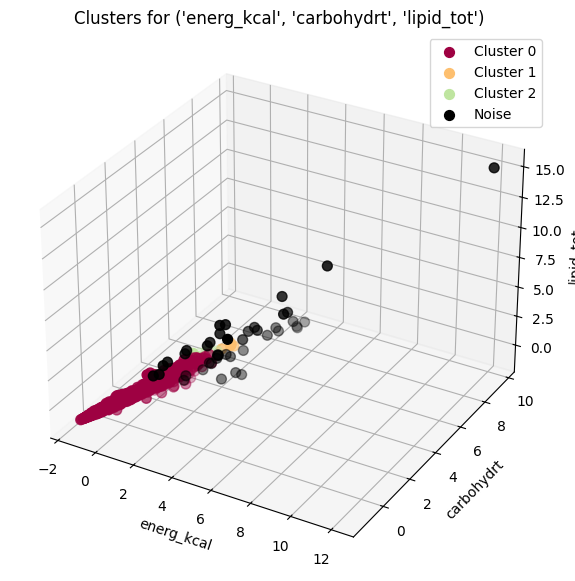

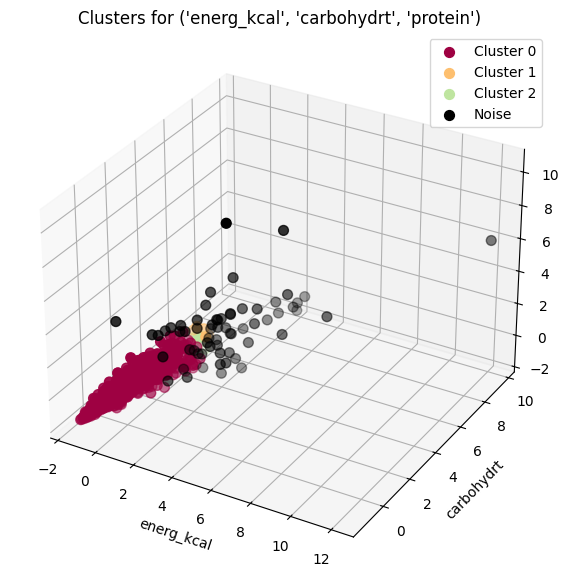

In [94]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Filtrar results_df para obtener los primeros 3 registros con 10 clusters
selected_results = results_df[results_df['n_clusters'] == 3].head(2)

# Graficar cada conjunto de columnas en 3D
for _, row in selected_results.iterrows():
    combo = row['columns']  # Obtener la combinación de columnas
    labels = row['labels']  # Etiquetas de los clusters
    df_subset = df_dqi_final_scaled[list(combo)]  # Subset del dataset original escalado

    # Crear figura 3D
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Negro para ruido
            col = [0, 0, 0, 1]
        class_member_mask = (np.array(labels) == k)
        xyz = df_subset[class_member_mask]

        ax.scatter(xyz.iloc[:, 0], xyz.iloc[:, 1], xyz.iloc[:, 2], color=tuple(col), label=f'Cluster {k}' if k != -1 else 'Noise', s=50)

    # Etiquetas de los ejes
    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])
    ax.set_zlabel(combo[2])
    
    # Leyenda y título
    ax.legend()
    ax.set_title(f"Clusters for {combo}")

    # Mostrar el gráfico
    plt.show()


Análisis bivariado con dfi_total

In [97]:
from joblib import Parallel, delayed
from sklearn.cluster import DBSCAN
import pandas as pd
from itertools import combinations

# Lista de columnas numéricas excluyendo dqi_total
columns = [col for col in df_dqi_final_scaled.columns if col != 'dqi_total']

# Definir la función de DBSCAN para una combinación con dqi_total como referencia
def run_dbscan(combo):
    # Agregar 'dqi_total' a cada combinación de 2 columnas
    df_subset = df_dqi_final_scaled[['dqi_total'] + list(combo)]
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan.fit(df_subset)
    labels = dbscan.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    return {'columns': ('dqi_total',) + combo, 'n_clusters': n_clusters_, 'n_noise': n_noise_, 'labels': labels}

# Ejecutar en paralelo usando joblib
all_results = Parallel(n_jobs=-1)(delayed(run_dbscan)(combo) for combo in combinations(columns, 2))

# Convertir a DataFrame para visualizar resultados
results_df_2cols = pd.DataFrame(all_results)
results_df_2cols.head()


,columns,n_clusters,n_noise,labels
0,"(dqi_total, energ_kcal, carbohydrt)",2,48,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
1,"(dqi_total, energ_kcal, lipid_tot)",2,47,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
2,"(dqi_total, energ_kcal, protein)",1,60,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
3,"(dqi_total, energ_kcal, fiber_td)",1,64,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."
4,"(dqi_total, energ_kcal, calcium)",2,67,"[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0,..."


<Axes: title={'center': 'Top 10 Número de Clusters Encontrados'}, xlabel='n_clusters'>

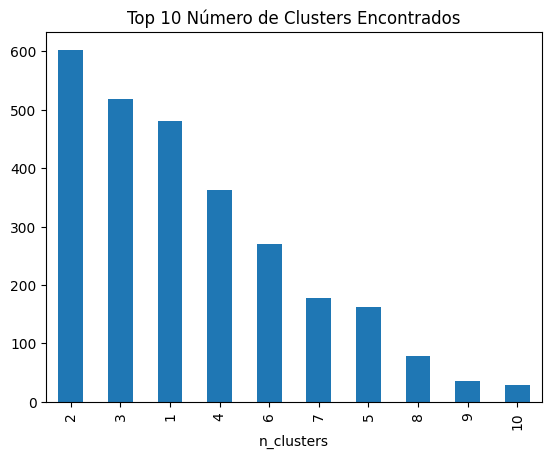

In [99]:
# resultados de results_df_2cols
top_10_clusters = results_df_2cols['n_clusters'].value_counts().head(10)
top_10_clusters.plot(kind='bar', title='Top 10 Número de Clusters Encontrados')